In [207]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field
from typing import TypedDict, List, Annotated, Literal
import operator
from langchain_core.prompts import ChatPromptTemplate
from langgraph.types import Send
from langgraph.graph import  StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama
from langchain_community.tools import DuckDuckGoSearchRun
# from duckduckgo_search import DDGS
from ddgs import DDGS
import requests
from typing import Optional
from langchain_community.tools import tool
from typing import Dict
import base64

load_dotenv()

True

In [208]:


class Task(BaseModel):
    id: int
    title: str
    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=5,
        description="3-5 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(
        ...,
        description="Target word count for this section (120-450).",
    )
    section_type: Literal[
        "intro", "core", "examples", "checklist", "common_mistakes", "conclusion"
    ] = Field(
        ...,
        description="Use 'common_mistakes' and 'examples' exactly once in the plan.",
    )
class Plan(BaseModel):
    blog_title: str = Field(..., description="A catchy and highly technical title for the blog post.")
    audience: str = Field(..., description="Who this blog is for.")
    tone: str = Field(..., description="Writing tone (e.g., practical, crisp).")
    tasks: List[Task]
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"




class RouterDecision(BaseModel):
    """Decide if the topic requires real-time web research."""
    needs_research: bool = Field(
        description="Whether the topic requires external web search (True) or not (False)."
    )
    reason: str = Field(
        description="Brief explanation of why research is or isn't needed."
    )
    queries: List[str] = Field(default_factory=list, description="high-signal queries")


class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # keep if web search provides; DO NOT rely on it
    snippet: Optional[str] = None
    source: Optional[str] = None

class EvidenceWrapper(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)


class ImageSpec(BaseModel):
    placeholder: str = Field(..., description="eg: [[IMAGE_1]]")
    filename: str = Field(..., description="Save under images/, e.g. qkv_flow.png")
    alt: str
    caption: str
    prompt: str = Field(..., description="Prompt to send to the image model.")
    # size: Literal["1024x1024", "1024x1536", "1536x1024"] = "1024x1024"
    # quality: Literal["low", "medium", "high"] = "medium"

class GlobalImagePlan(BaseModel):
    md_with_placeholders: str
    images: List[ImageSpec] = Field(default_factory=list)


class State(TypedDict):
    topic: str

    # routing / research
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]
    router_decision : RouterDecision

    # workers
    sections: Annotated[List[tuple[int, str]], operator.add]  # (task_id, section_md)

    # reducer/image
    merged_md: str
    md_with_placeholders: str
    image_specs: List[ImageSpec]
    verified_images: Dict[str, str]

    final: str


In [209]:
def get_gemini_llm():
    return ChatGoogleGenerativeAI(model='models/gemini-2.5-flash')

def get_ollama_llm():
    return ChatOllama(model="llama3")

def get_groq_llm():
    return ChatGroq(model="llama-3.1-8b-instant")

In [210]:
def router_node(state : State):
    topic = state["topic"]
    print(f"\n--- [ROUTER] Analyzing topic: {topic} ---")

    system_prompt = """You are an intelligent routing module for an AI research agent.\nYour objective is to analyze a user's topic and determine if external web research is required before generating a response.\n
    If needs_research=true:\n
    - Output 3-10 high-signal queries.
    - Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
    - If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES..
    """

    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", "Topic: {topic}")
    ])

    chain = prompt | get_ollama_llm().with_structured_output(RouterDecision)
    result = chain.invoke({"topic": topic})

    print(f"Decision: {'Research Needed' if result.needs_research else 'Direct Orchestration'}")
    if result.needs_research:
        print(f"Queries: {result.queries}")

    return {
        "router_decision": result.model_dump()
    }


def route_next(state: State) -> str:
    route_decision = RouterDecision(**state["router_decision"])
    return "research" if route_decision.needs_research else "orchestrator"

In [211]:
# web search based on query and url


def _searxng_search(query: str, max_results: int = 5) -> List[dict]:
    """Helper function to fetch and normalize results from local SearxNG."""
    url = "http://localhost:8080/search"

    params = {
        "q": query,
        "format": "json",
        "engines": "google,bing,duckduckgo", # Add/remove engines as needed
        "language": "en-US"
    }

    try:
        response = requests.get(url=url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()

        normalized: List[dict] = []

        for r in data.get("results", [])[:max_results]:
            normalized.append({
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date"), 
                #SearxNG uses this for some engines
                "source": r.get("engine"),
            })
        return normalized
    except Exception as e:
        print(f"Error calling SearxNG: {e}")
        return []
    
@tool
def search_specific_site(query: str, site: str, max_results: int = 5) -> List[dict]:
    """
    Search for information within a specific website only.
    Use this when you have a high-quality source (like docs.python.org) 
    and need to find specific details within it.
    
    Args:
        query: The search term or question.
        site: The domain to search (e.g., 'wikipedia.org', 'github.com').
        max_results: How many results to return.
    """
    full_query = f"site:{site} {query}"
    results = _searxng_search(full_query, max_results=max_results)

    if not results:
        return "No results found for this site search."
            
    # Convert the list of dicts into a readable string for the LLM
    formatted_results = []
    for r in results:
        formatted_results.append(f"Title: {r['title']}\nSnippet: {r['snippet']}\nURL: {r['url']}")
        
    return "\n\n---\n\n".join(formatted_results)


In [212]:
def research_node(state : State) -> dict:
    router_decision = state["router_decision"]
    queries = (router_decision.get("queries", []) or [])
    print(f"\n--- [RESEARCHER] Gathering evidence for {len(queries)} queries ---")

    system_message = """You are a Specialized Research Extraction Agent. 

    Your goal is to transform raw, messy search engine results into a structured 'Evidence Pack'. 

    ### GUIDELINES:
    1. **Veracity First**: Only extract information that is explicitly stated in the snippets. Do not hallucinate details or "fill in the blanks."
    2. **Signal-to-Noise**: Ignore results that are clearly advertisements, cookie consent text, or irrelevant SEO filler.
    3. **Temporal Awareness**: If multiple results conflict, prioritize the one with the most recent 'published_at' date or the most authoritative 'source'.
    4. **Snippet Preservation**: Keep the 'snippet' meaningful. Do not summarize it so much that the specific data points (numbers, names, specs) are lost.
    5. **No Commentary**: Do not explain your choices. Simply output the filtered EvidenceItem list.

    ### OUTPUT EXPECTATION:
    You must return a valid EvidencePack. Each EvidenceItem must have a valid URL. If no relevant results are found, return an empty list."""

    raw_results: List[dict] = []

    for q in queries:
        print(f"  Searching for: {q}...")
        raw_results.extend(_searxng_search(q, max_results=3))

    if not raw_results:
        print("  No raw results found.")
        return {"evidence": []}
    
    print(f"  Found {len(raw_results)} snippets. Extracting structured evidence...")
    exctractor = get_ollama_llm().with_structured_output(EvidenceWrapper)
    pack = exctractor.invoke([
        ("system", system_message),
        ("human", f"Raw results:\n{raw_results}")
    ])

    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e

    print(f"  Research complete. {len(dedup)} unique evidence items identified.")
    return {"evidence": list(dedup.values())} 

In [213]:
def orchestrator_node(state : State) -> dict:
    planner = get_ollama_llm().with_structured_output(Plan)
    orchestrator_system_message = """You are a Master Content Architect and Editor-in-Chief.
    Your goal is to create a detailed, high-signal execution plan for a technical blog post.

    ### YOUR INPUTS:
    1. **Topic**: The core subject requested by the user.
    2. **Scout Evidence**: Brief snippets from the web to ground your planning in current reality (e.g., current versions, recent news, existing controversies).

    ### YOUR MISSION:
    - **Determine Blog Kind**: Analyze the Topic and select the exact `blog_kind` that best fits the intent.
    - **Structure by Kind**: Tailor your logical task breakdown strictly to the chosen format:
        - *tutorial*: Step-by-step implementation, prerequisites, and code execution flow.
        - *system_design*: Architecture, component breakdowns, data flow, and system trade-offs.
        - *comparison*: Feature-by-feature analysis, pros/cons, and clear use-case recommendations.
        - *explainer*: Core concepts, mental models, and "how it works" under the hood.
        - *news_roundup*: Recent updates, release features, and industry impact analysis.
    - **Precision**: For each task, write a 'goal' and 'bullets' that are so specific that a worker with no context could write a perfect section.
    - **Research Guidance**: Provide 2-3 specific search queries for the workers to use for deep-diving into their specific section.
    - **Variety**: Ensure the 'section_type' distribution follows the requirements (using 'examples' and 'common_mistakes' exactly once).

    ### CRITICAL RULES:
    - If the 'Scout Evidence' mentions specific version numbers (e.g., Python 3.13) or dates, ensure the Plan reflects these.
    - Do not create more than 5-6 tasks total to ensure the blog remains focused.
    - Ensure the 'target_words' for the entire blog totals between 1000-1500 words."""

    evidence = state.get("evidence", [])
    evidence_str = ""

    if evidence:
        for i,e in enumerate(evidence[:10]):
            evidence_str += f"[{i+1}] {e.title}\n   Snippet: {e.snippet}\n   URL: {e.url}\n\n"
    else:
        evidence_str = "No recent search evidence found. Plan based on general knowledge."

    
    plan = planner.invoke([
        ("system", orchestrator_system_message),
        ("human", f"Topic: {state['topic']}\nScout Evidence:\n{evidence_str}")
    ])

    print(f"  Plan generated: {plan.blog_title}")
    print(f"  Audience: {plan.audience}")
    print(f"  Sections: {[t.title for t in plan.tasks]}")
    return {"plan": plan.model_dump()}

In [214]:
def fanout(state: State):
    """
    This function reads the plan and spawns parallel workers.
    """
    # plan = state.get("plan")
    plan = Plan(**state["plan"])
    if not plan or not plan.tasks:
        return [] # Or go to END
    
    print(f"--- [FANOUT] Spawning {len(plan.tasks)} parallel workers ---")

    return [
        Send("worker", {
            "task": task.model_dump(),
            "topic": state["topic"],
            "plan": plan.model_dump(),
            "evidence": [e.model_dump() for e in state.get("evidence", [])]
        })
        for task in plan.tasks
    ]

In [215]:
def clean(text: str) -> str:
    if not text: return "---"
    # Remove pipes and newlines so the Markdown table doesn't break
    return text.replace("|", "-").replace("\n", " ").strip()


def worker(payload: dict) -> dict:
    plan = Plan(**payload["plan"])
    task = Task(**payload["task"])
    topic = payload.get("topic", "")
    print(f"  --- [WORKER] Writing section: {task.title} ({task.target_words} words) ---")
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]

    bullets_text = "\n- " + "\n- ".join(task.bullets)
    
    evidence_header = "| Title | URL | Date | Snippet |"
    evidence_divider = "|-------|-----|------|---------|"
    evidence_table = ""

    if evidence:
        rows = [
            f"| {clean(e.title)} | {e.url} | {clean(e.published_at)} | {clean(e.snippet)} |"
            for e in evidence[:20]
        ]
        evidence_table = "\n".join([evidence_header, evidence_divider] + rows)
    else:
        evidence_table = "No evidence available."


    system_prompt = f"""You are a professional Technical Writer. 
    Your goal is to write the '{task.section_type}' section of a blog post titled: "{plan.blog_title}".
    
    WRITING STYLE:
    - Audience: {plan.audience}
    - Tone: {plan.tone}
    - Blog Kind: {plan.blog_kind}
    - Standards: Use clean Markdown. Be precise, technical, and avoid fluff.
    """
    
    human_message = f"""Please write the following section for our blog about '{topic}'.

    SECTION TITLE: {task.title}
    GOAL: {task.goal}
    
    KEY POINTS TO COVER:
    {bullets_text}

    RESEARCH EVIDENCE TO USE:
    {evidence_table}

    REQUIREMENTS:
    - Length: Approximately {task.target_words} words.
    - Format: Use Markdown headers (##) and bolding for key terms.
    - If there is a URL in the evidence that is highly relevant, cite it.
    """
    tools = [search_specific_site]
    llm_with_tools = get_groq_llm().bind_tools(tools)

    # response = llm_with_tools.invoke([
    #     ("system", system_prompt),
    #     ("human", human_message)
    # ])

    # # Return a tuple with (id, content) so the Reducer can sort them correctly
    # return {"sections": [(task.id, response.content)]}


    try:
        response = llm_with_tools.invoke([
            ("system", system_prompt),
            ("human", human_message)
        ])
        print(f"  ✓ [WORKER] Finished section: {task.title}")
        return {"sections": [(task.id, response.content)]}
    except Exception as e:
        print(f"❌ Worker failed for section '{task.title}': {e}")
        # Return a safe fallback so the Reducer subgraph doesn't crash
        fallback_content = f"## {task.title}\n\n*Error: The AI writer failed to generate this section due to an API timeout. Please regenerate.*"
        return {"sections": [(task.id, fallback_content)]}

In [216]:
def merge_node(state: State) -> dict:
    # 1. Safely handle the plan (whether it is a Dict or a Pydantic object)
    raw_plan = state.get("plan", {})
    blog_title = raw_plan.get("blog_title", "Generated Blog") if isinstance(raw_plan, dict) else raw_plan.blog_title

    # 2. Sort the sections by task_id
    sorted_items = sorted(state.get("sections", []), key=lambda x: x[0])
    print(f"\n--- [MERGER] Assembling {len(sorted_items)} sections into full blog ---")
    
    ordered_sections = []
    for item in sorted_items:
        md = item[1] # This is the content that threw the error
        
        # 3. CRITICAL FIX: Force the markdown to be a string
        if isinstance(md, list):
            # If the LLM returned a list of dicts (LangChain message blocks)
            if len(md) > 0 and isinstance(md[0], dict) and "text" in md[0]:
                md = md[0]["text"]
            else:
                # If it's just accidentally wrapped in a standard list
                md = str(md[0]) if len(md) > 0 else ""
        elif not isinstance(md, str):
            md = str(md) # Catch-all for any other weird types
            
        ordered_sections.append(md.strip())

    # 4. Join the safely extracted strings
    body = "\n\n".join(ordered_sections).strip()

    merged_md = f"# {blog_title}\n\n{body}\n"
    
    # Return both keys for safety as we discussed earlier
    return {"merged_md": merged_md, "final": merged_md}

In [217]:
def should_fetch_images(state: State) -> str:
    """Check if the planner actually requested any images."""
    specs = state.get("image_specs", [])

    if len(specs) > 0:
        return "verify"
    else:
        return "skip"

In [218]:
def image_planner_node(state: State) -> dict:
    print(f"\n--- [IMAGE PLANNER] Designing visual aids ---")
    planner = get_gemini_llm().with_structured_output(GlobalImagePlan)

    raw_plan = state.get("plan", {})
    if isinstance(raw_plan, dict):
        blog_kind = raw_plan.get("blog_kind", "explainer")
    else:
        blog_kind = getattr(raw_plan, "blog_kind", "explainer")

    system_message = """You are a Technical Visual Content Strategist. 
    Analyze the blog Markdown and identify where visual aids (diagrams, flowcharts, or technical photos) will add value.

    ACTION:
    1. Insert placeholders like [[IMAGE_1]], [[IMAGE_2]] directly into the text where they provide the most impact.
    2. For every placeholder, create a detailed ImageSpec.

    ### QUERY GENERATION RULES FOR SEARXNG:
    - The 'prompt' field MUST be a search-engine-optimized query.
    - Use technical keywords, not descriptive prose. (e.g., Use "Python JIT compiler architecture diagram" instead of "A drawing showing how a JIT compiler works").
    - Add qualifiers like "diagram", "flowchart", "architecture", or "screenshot" to the query to ensure professional results.
    - Avoid aesthetic words like "beautiful", "high-quality", or "cinematic" as they pollute search results.

    ### SECTION CONTEXT:
    - Ensure the image matches the 'blog_kind' ({state['plan'].blog_kind}). 
    - If it's a 'tutorial', prioritize screenshots or code-flow diagrams.
    - If it's a 'system_design', prioritize architectural patterns."""

    image_plan = planner.invoke([
        ("system", system_message),
        ("human", f"Blog kind: {blog_kind}\nTopic: {state['topic']}\nBlog Content:\n{state['merged_md']}")
    ])

    print(f"  Added {len(image_plan.images)} image placeholders.")
    return {
        "md_with_placeholders": image_plan.md_with_placeholders,
        "image_specs": [img.model_dump() for img in image_plan.images] # Store these for the Generator node
    }

In [219]:


def _searxng_image_search(query: str, max_results: int = 3) -> str:
    """Fetches top 3 image URLs and their metadata from SearxNG."""

    url = "http://localhost:8080/search"
    params = {
        "q": query,
        "format": "json",
        "categories": "images",
        "engines": "google images,bing images"
    }
    try:
        response = requests.get(url, params=params, timeout=10)
        return response.json().get("results", [])[:3]
    except:
        return []
    

def _download_image_as_base64(url: str) -> str:
    """Downloads an image and converts it to base64 for the Vision LLM."""
    try:
        res = requests.get(url, timeout=5)
        if res.status_code == 200:
            return base64.b64encode(res.content).decode("utf-8")
    except:
        return None

In [220]:
def image_verification_node(state: State) -> dict:
    print(f"\n--- [IMAGE VERIFIER] Searching and verifying images ---")
    # specs: List[ImageSpec] = state.get("image_specs", [])
    llm = get_groq_llm()
    
    # This dictionary will store our final choices
    verified_images = {}
    
    raw_specs = state.get("image_specs", [])
    specs = [ImageSpec(**raw_dict) for raw_dict in raw_specs]

    for spec in specs:
        print(f"  Verifying image for: {spec.alt}...")
        # 1. Fetch candidates from SearxNG
        candidates = _searxng_image_search(spec.prompt) # This returns the List[dict]
        
        if not candidates:
            continue

        # 2. Build the metadata string for the LLM to judge
        metadata_summary = "\n".join([
            f"ID {i}: Title: {c['title']} | Source: {c['source']}"
            for i, c in enumerate(candidates)
        ])

        # 3. Ask LLM to pick the index
        prompt = f"""Target Image: {spec.alt}
        {metadata_summary}
        
        Which ID is the most relevant and high-quality technical image for this topic? 
        Return ONLY the number."""

        try:
            response = llm.invoke(prompt).content.strip()
            # Basic cleaning in case LLM adds a period or extra text
            best_index = int(''.join(filter(str.isdigit, response)))
            
            if 0 <= best_index < len(candidates):
                best_url = candidates[best_index]['img_src']
                # Store the winner in our map
                verified_images[spec.placeholder] = best_url
        except Exception as e:
            print(f"Error verifying image {spec.placeholder}: {e}\nFallback to default image")
            if(len(candidates) > 0):
                verified_images[spec.placeholder] = candidates[0]['img_src']

    # We return the dictionary, which LangGraph saves to the state
    return {"verified_images": verified_images}

In [221]:
def image_placement_node(state: State) -> dict:
    print(f"\n--- [IMAGE PLACEMENT] Finalizing blog with images ---")
    current_md = state.get("md_with_placeholders", "")
    verified_images = state.get("verified_images", {})
    # specs = state.get("image_specs", [])

    final_md = current_md 

    raw_specs = state.get("image_specs", [])
    specs = [ImageSpec(**raw_specs) for raw_dict in raw_specs]

    for spec in specs:
        placeholder = spec.placeholder
        if placeholder in verified_images:
            url = verified_images[placeholder]
            image_markdown = f"\n\n![{spec.alt}]({url})\n*Figure: {spec.caption}*\n\n"
            final_md = final_md.replace(placeholder, image_markdown)
        else:
            # Cleanup stray placeholders
            final_md = final_md.replace(placeholder, "")
    
    return {"final": final_md} # Ensure this matches your State['final'] key

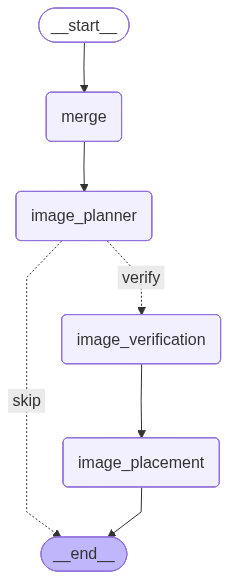

In [222]:
reducer_graph = StateGraph(State)

reducer_graph.add_node("merge", merge_node)
reducer_graph.add_node("image_planner", image_planner_node)
reducer_graph.add_node("image_verification", image_verification_node)
reducer_graph.add_node("image_placement", image_placement_node)

reducer_graph.add_edge(START, "merge")
reducer_graph.add_edge("merge", "image_planner")

reducer_graph.add_conditional_edges(
    "image_planner",
    should_fetch_images,
    {
        "verify": "image_verification",
        "skip": END
    }
)
# reducer_graph.add_edge("image_planner", "image_verification")
reducer_graph.add_edge("image_verification", "image_placement")
reducer_graph.add_edge("image_placement", END)


reducer_subgraph = reducer_graph.compile()
reducer_subgraph

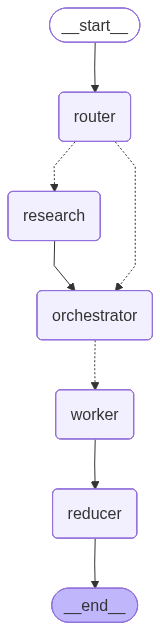

In [223]:
graph = StateGraph(State)

graph.add_node("router", router_node)
graph.add_node("research", research_node)
graph.add_node("orchestrator", orchestrator_node)
graph.add_node("worker", worker)
graph.add_node("reducer", reducer_subgraph)



graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    route_next,
    {
        "research": "research",
        "orchestrator": "orchestrator"
    }
)
graph.add_edge("research", "orchestrator")
graph.add_conditional_edges(
    "orchestrator", 
    fanout,
    ["worker"]
)
graph.add_edge("worker", "reducer")


workflow = graph.compile()
workflow

In [ ]:
# 1. Define the starting state with your chosen prompt
initial_state = {
    "topic": "Write a comprehensive system design blog post on building a Corrective Retrieval-Augmented Generation (CRAG) pipeline. Include the initial retrieval node, the evaluator node that grades documents, and the fallback web search mechanism. Explain how the data flows between these agents.",
    "plan": None,
    "evidence": [],
    "sections": [],
    "merged_md": "",
    "image_specs": [],
    "verified_images": {},
    "final": ""
}

# 2. Invoke the compiled graph (this will take a minute or two as parallel workers run!)
print("Starting the AI Blog Writer...")
final_state = workflow.invoke(initial_state)

# 3. Print the final result!
print("\n" + "="*50 + "\n")
print(final_state.get("final", "Error: No final output generated."))
print("\n" + "="*50 + "\n")

# Optional: Save it directly to a markdown file
with open("generated_blog.md", "w", encoding="utf-8") as f:
    f.write(final_state.get("final", ""))
    print("Saved to generated_blog.md!")

Starting the AI Blog Writer...
